In [1]:
import sys
import deepwalk_lesmis as dwlesmis
import numpy as np
from sklearn.cluster import SpectralClustering

In [2]:
def check_method(method):
    val = None
    if method == "kmedoids" or method =="Kmedoids":
        val = "kmedoids"
    elif method =="kmeans" or method == "Kmeans":
        val = "kmeans"
    else:
        sys.exit(f"methodの値が無効です method : {method}")
    return val

In [3]:
def check_data(data):
    data_list = ["football", "polbooks", "karateclub", "lesmis"]
    if data in data_list:
        pass
    else:
    
        sys.exit(f"変数dataの値が無効です data : {data}")

lesmisにはラベルが存在しません


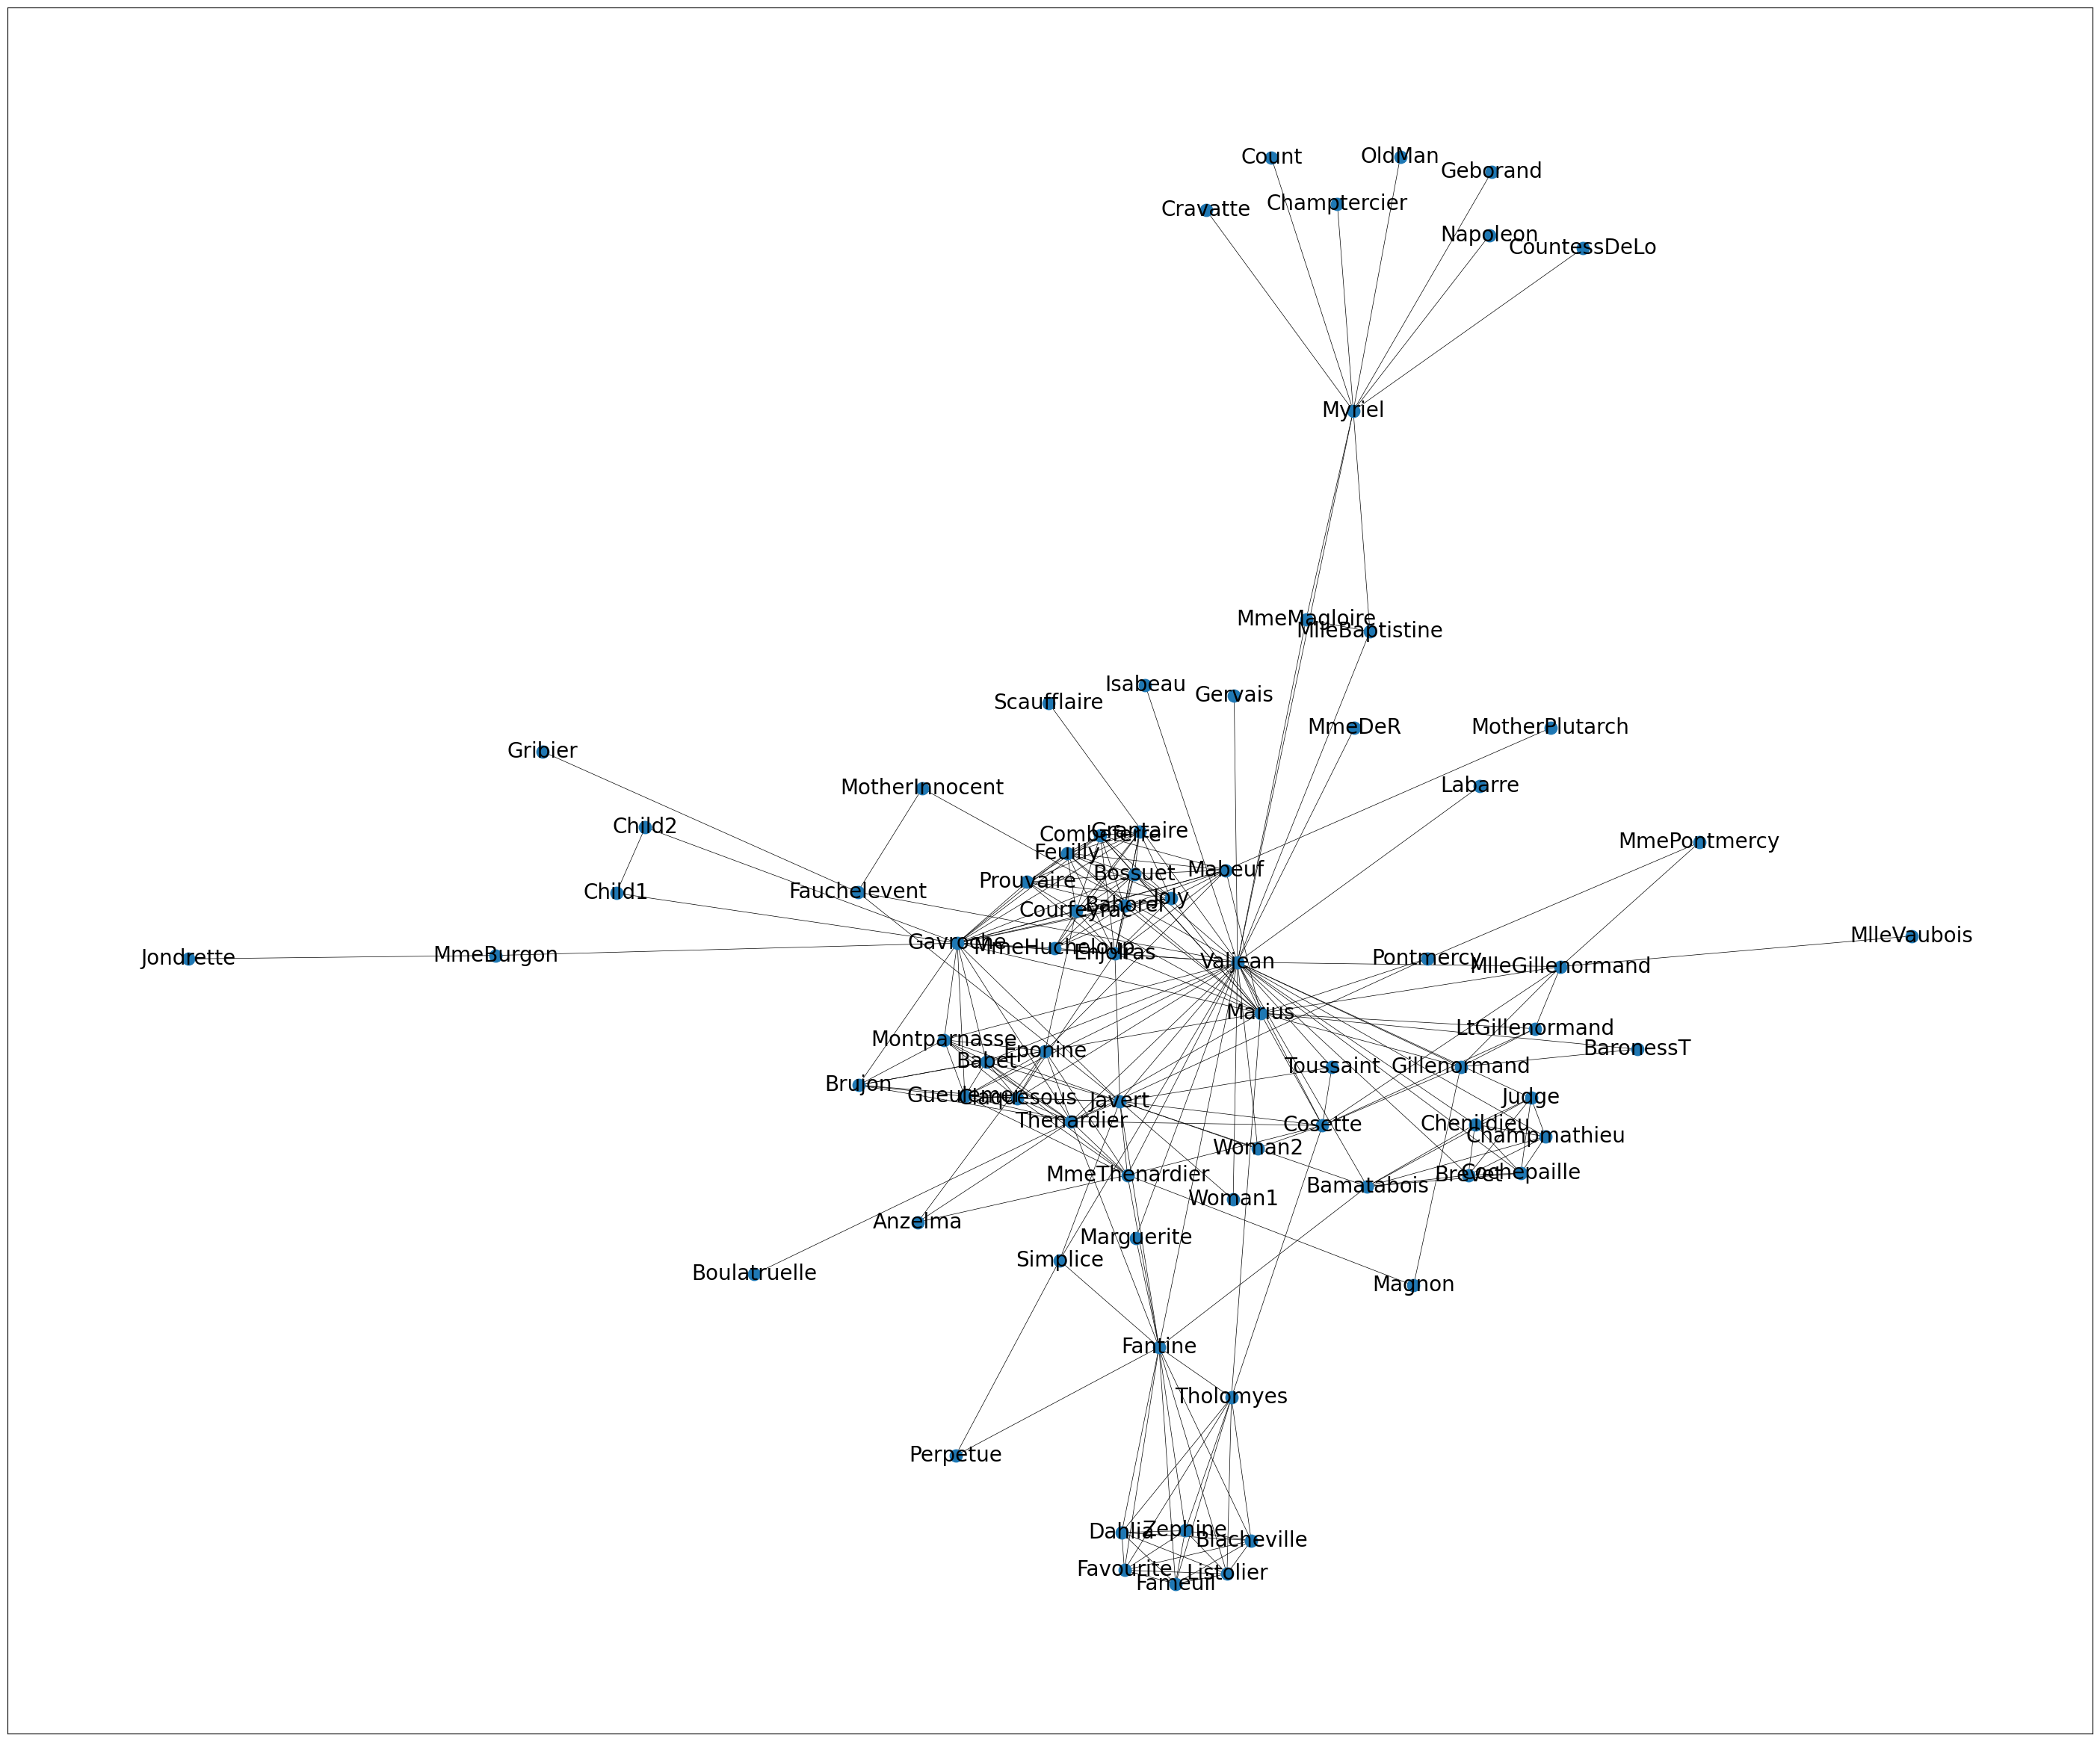

'\n以下はパラメータを変更して連続で実行する際に使用\n(for文でリストを与えて実行)\n\n# １ノードあたりの実行数\nNUMBER_WALKS_LIST = [1, 2, 4, 6, 8, 10, 15, 20, 25, 30]\n\n# 1ウォークあたりの長さ\nWALK_LENGTH_LIST = [5]\n\n# ウィンドウサイズリスト\nWINDOW_SIZE_LIST = [1, 2, 3, 4, 5,6,7,8,9,10]\n'

In [4]:
#実行回数(埋め込み-クラスタリング-ARI)
TIME = 10

data = "lesmis"
check_data(data)

# インプットするグラフ生成とラベルの取得(ラベルなしデータはNone)
INPUT, TRUE_LABEL = dwlesmis.generate_Graph("lesmis")

#インプットするグラフが無向グラフかどうか(True:無向グラフ,　False:有向グラフ)
UNDIRECTED = True




# １ノードあたりの実行数
NUMBER_WALKS =1000

# 1ウォークあたりの長さ
WALK_LENGTH = 100

# skipgramので使われるウィンドウサイズ
WINDOW_SIZE = 2




# ランダムシード値
SEED = 0

# 埋め込み後の各ノードの次元数
REPRESENTATION_SIZE = 2

# 並列プロセス数
WORKERS = 1

#クラスタ数
N_CLUSTER = 5

#クラスタリング手法
"""
kmedoids : "kmedoids"
kmeans   : "kmeans"
"""
METHOD = check_method("kmeans")

#結果を表示するかどうか
SHOW = False

#注目するノードリスト
ATTENTION_NODE_LIST = ["Valjean","Marius"]

"""
以下はパラメータを変更して連続で実行する際に使用
(for文でリストを与えて実行)

# １ノードあたりの実行数
NUMBER_WALKS_LIST = [1, 2, 4, 6, 8, 10, 15, 20, 25, 30]

# 1ウォークあたりの長さ
WALK_LENGTH_LIST = [5]

# ウィンドウサイズリスト
WINDOW_SIZE_LIST = [1, 2, 3, 4, 5,6,7,8,9,10]
"""

In [5]:
"""
    グラフ生成
    G = from_networkx(INPUT:networkxグラフインスタンス, 無効グラフかどうか:boolean)
    """
G = dwlesmis.from_networkx(INPUT, True)
# ノード数出力
print("Number of nodes: {}".format(len(G.nodes())))

# ウォーク数算出(ノード数*1ノードあたりのウォーク数)と出力
num_walks = len(G.nodes()) * NUMBER_WALKS
print("Number of walks: {}".format(num_walks))

# データサイズ(ウォーク数*ウォークの長さ)の算出と出力
data_size = num_walks * WALK_LENGTH
print("Data size (walks*length): {}".format(data_size))

Number of nodes: 77
Number of walks: 77000
Data size (walks*length): 7700000


In [6]:
vec,walks = dwlesmis.embed(INPUT, UNDIRECTED, NUMBER_WALKS, WALK_LENGTH, REPRESENTATION_SIZE, WINDOW_SIZE, WORKERS)


In [7]:
node_annotation = [i for i in INPUT.nodes()]

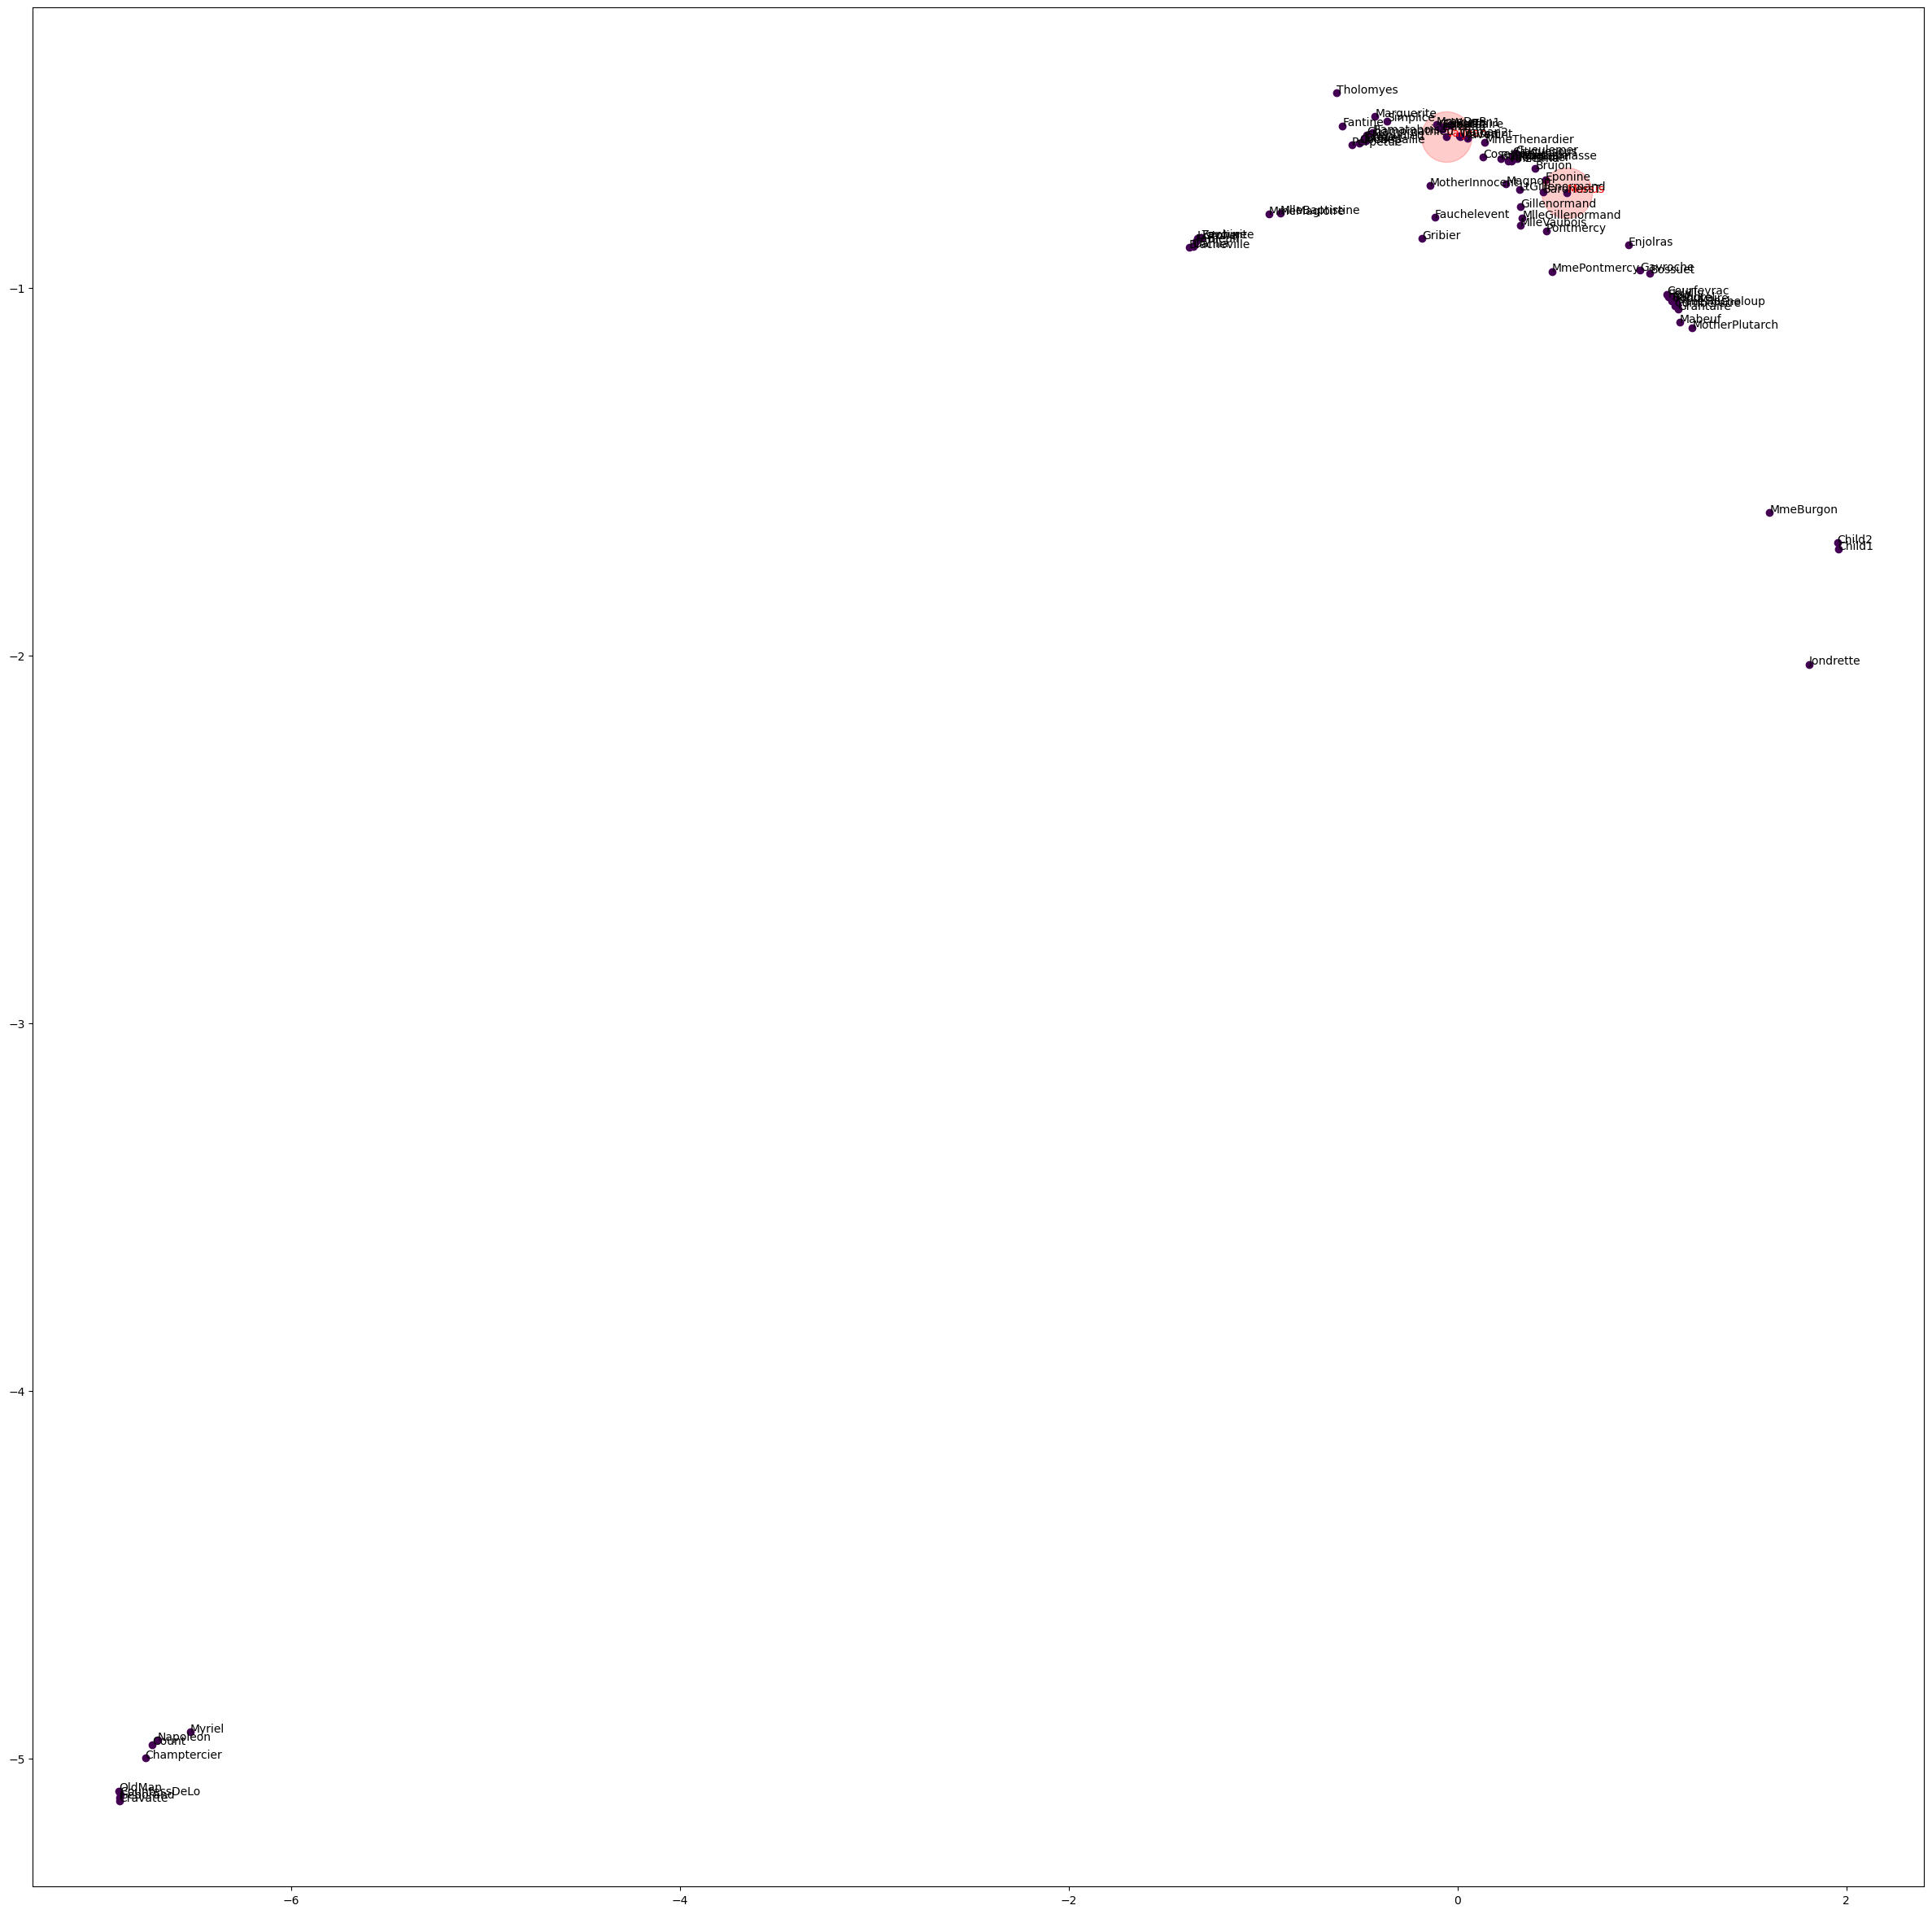

In [8]:
dwlesmis.draw_embedded_vector(vec,node_annotation=node_annotation,ATTENTION_NODE_LIST=ATTENTION_NODE_LIST)

In [9]:
#vecをkmeansでクラスタリング

pred = dwlesmis.clustering(vec, N_CLUSTER, METHOD)
    

In [10]:


#pred = SpectralClustering(n_clusters=N_CLUSTER, affinity='nearest_neighbors', n_init=100).fit_predict(vec)
   


In [11]:
colors = []
for i in pred:
    if i == 0:
        colors.append("red")
    elif i == 1:
        colors.append("blue")
    elif i == 2:
        colors.append("green")
    elif i == 3:
        colors.append("teal")
    elif i == 4:
        colors.append("purple")
    elif i == 5:
        colors.append("orange")
    elif i == 6:
        colors.append("pink")
    elif i == 7:
        colors.append("brown")
    elif i == 8:
        colors.append("gray")
    elif i == 9:
        colors.append("black")
    else:
        colors.append("white")


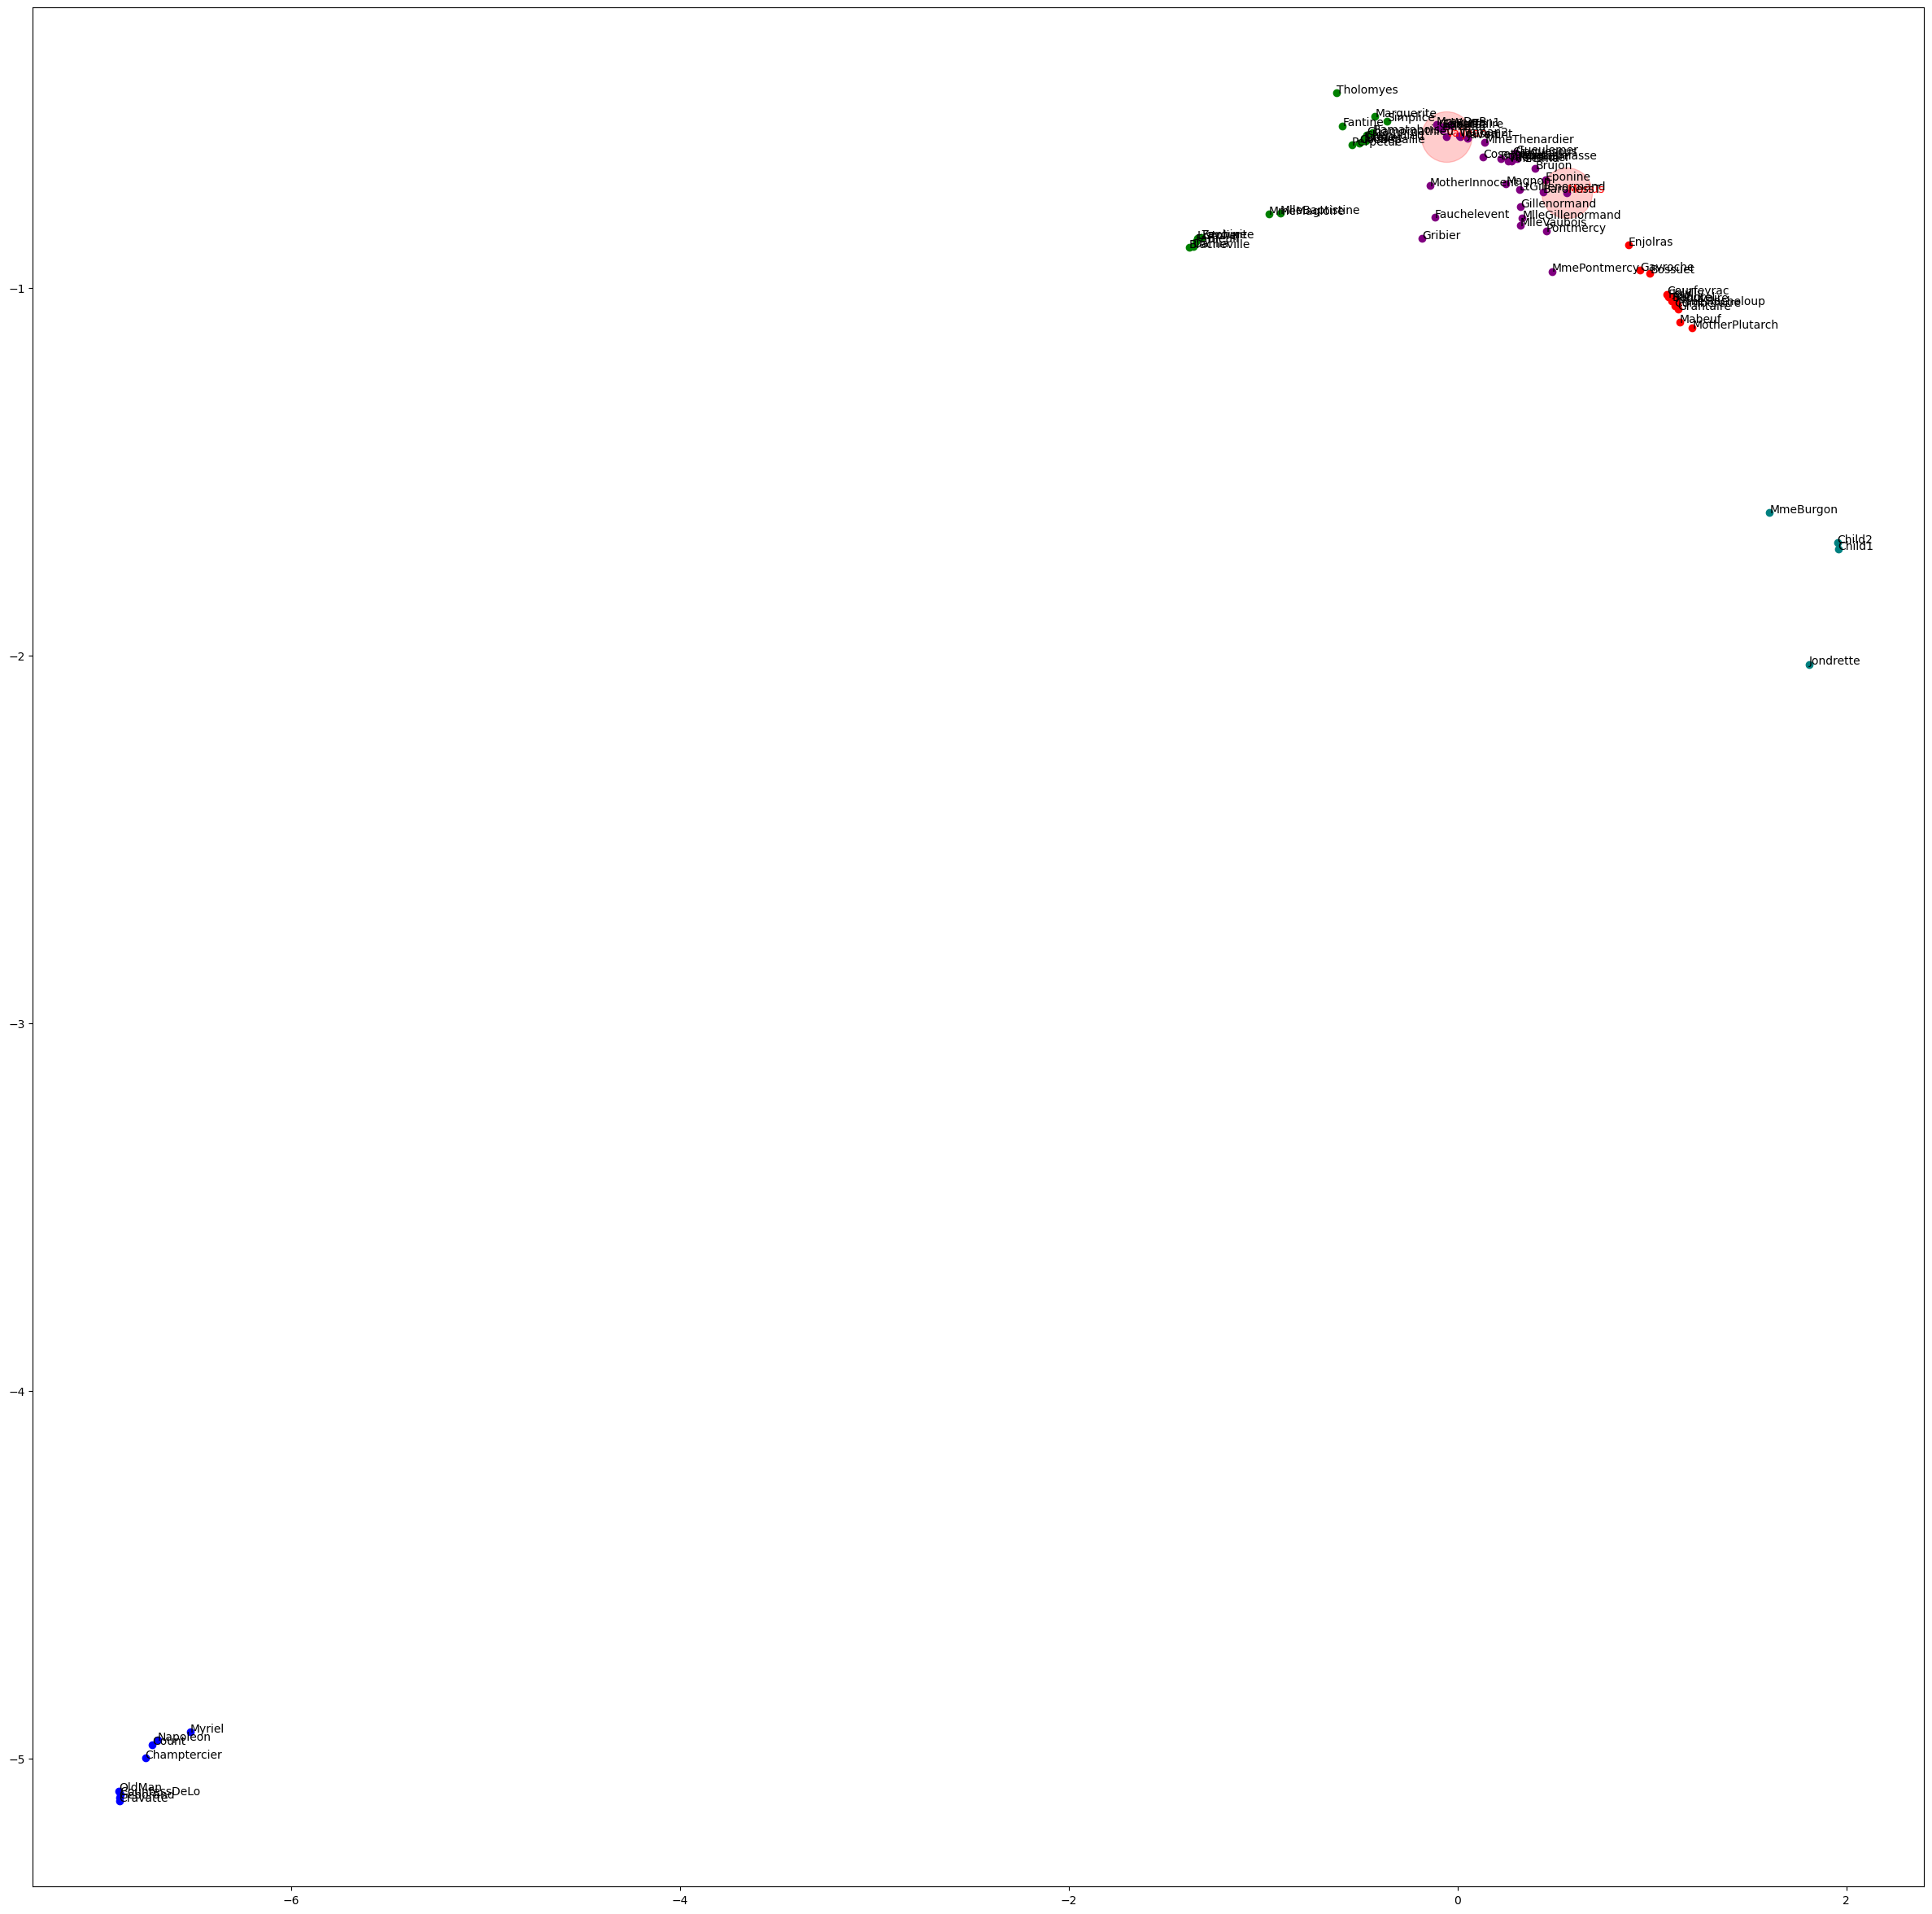

In [12]:
dwlesmis.draw_embedded_vector(vec,colorlist=colors,node_annotation=node_annotation,ATTENTION_NODE_LIST=ATTENTION_NODE_LIST)

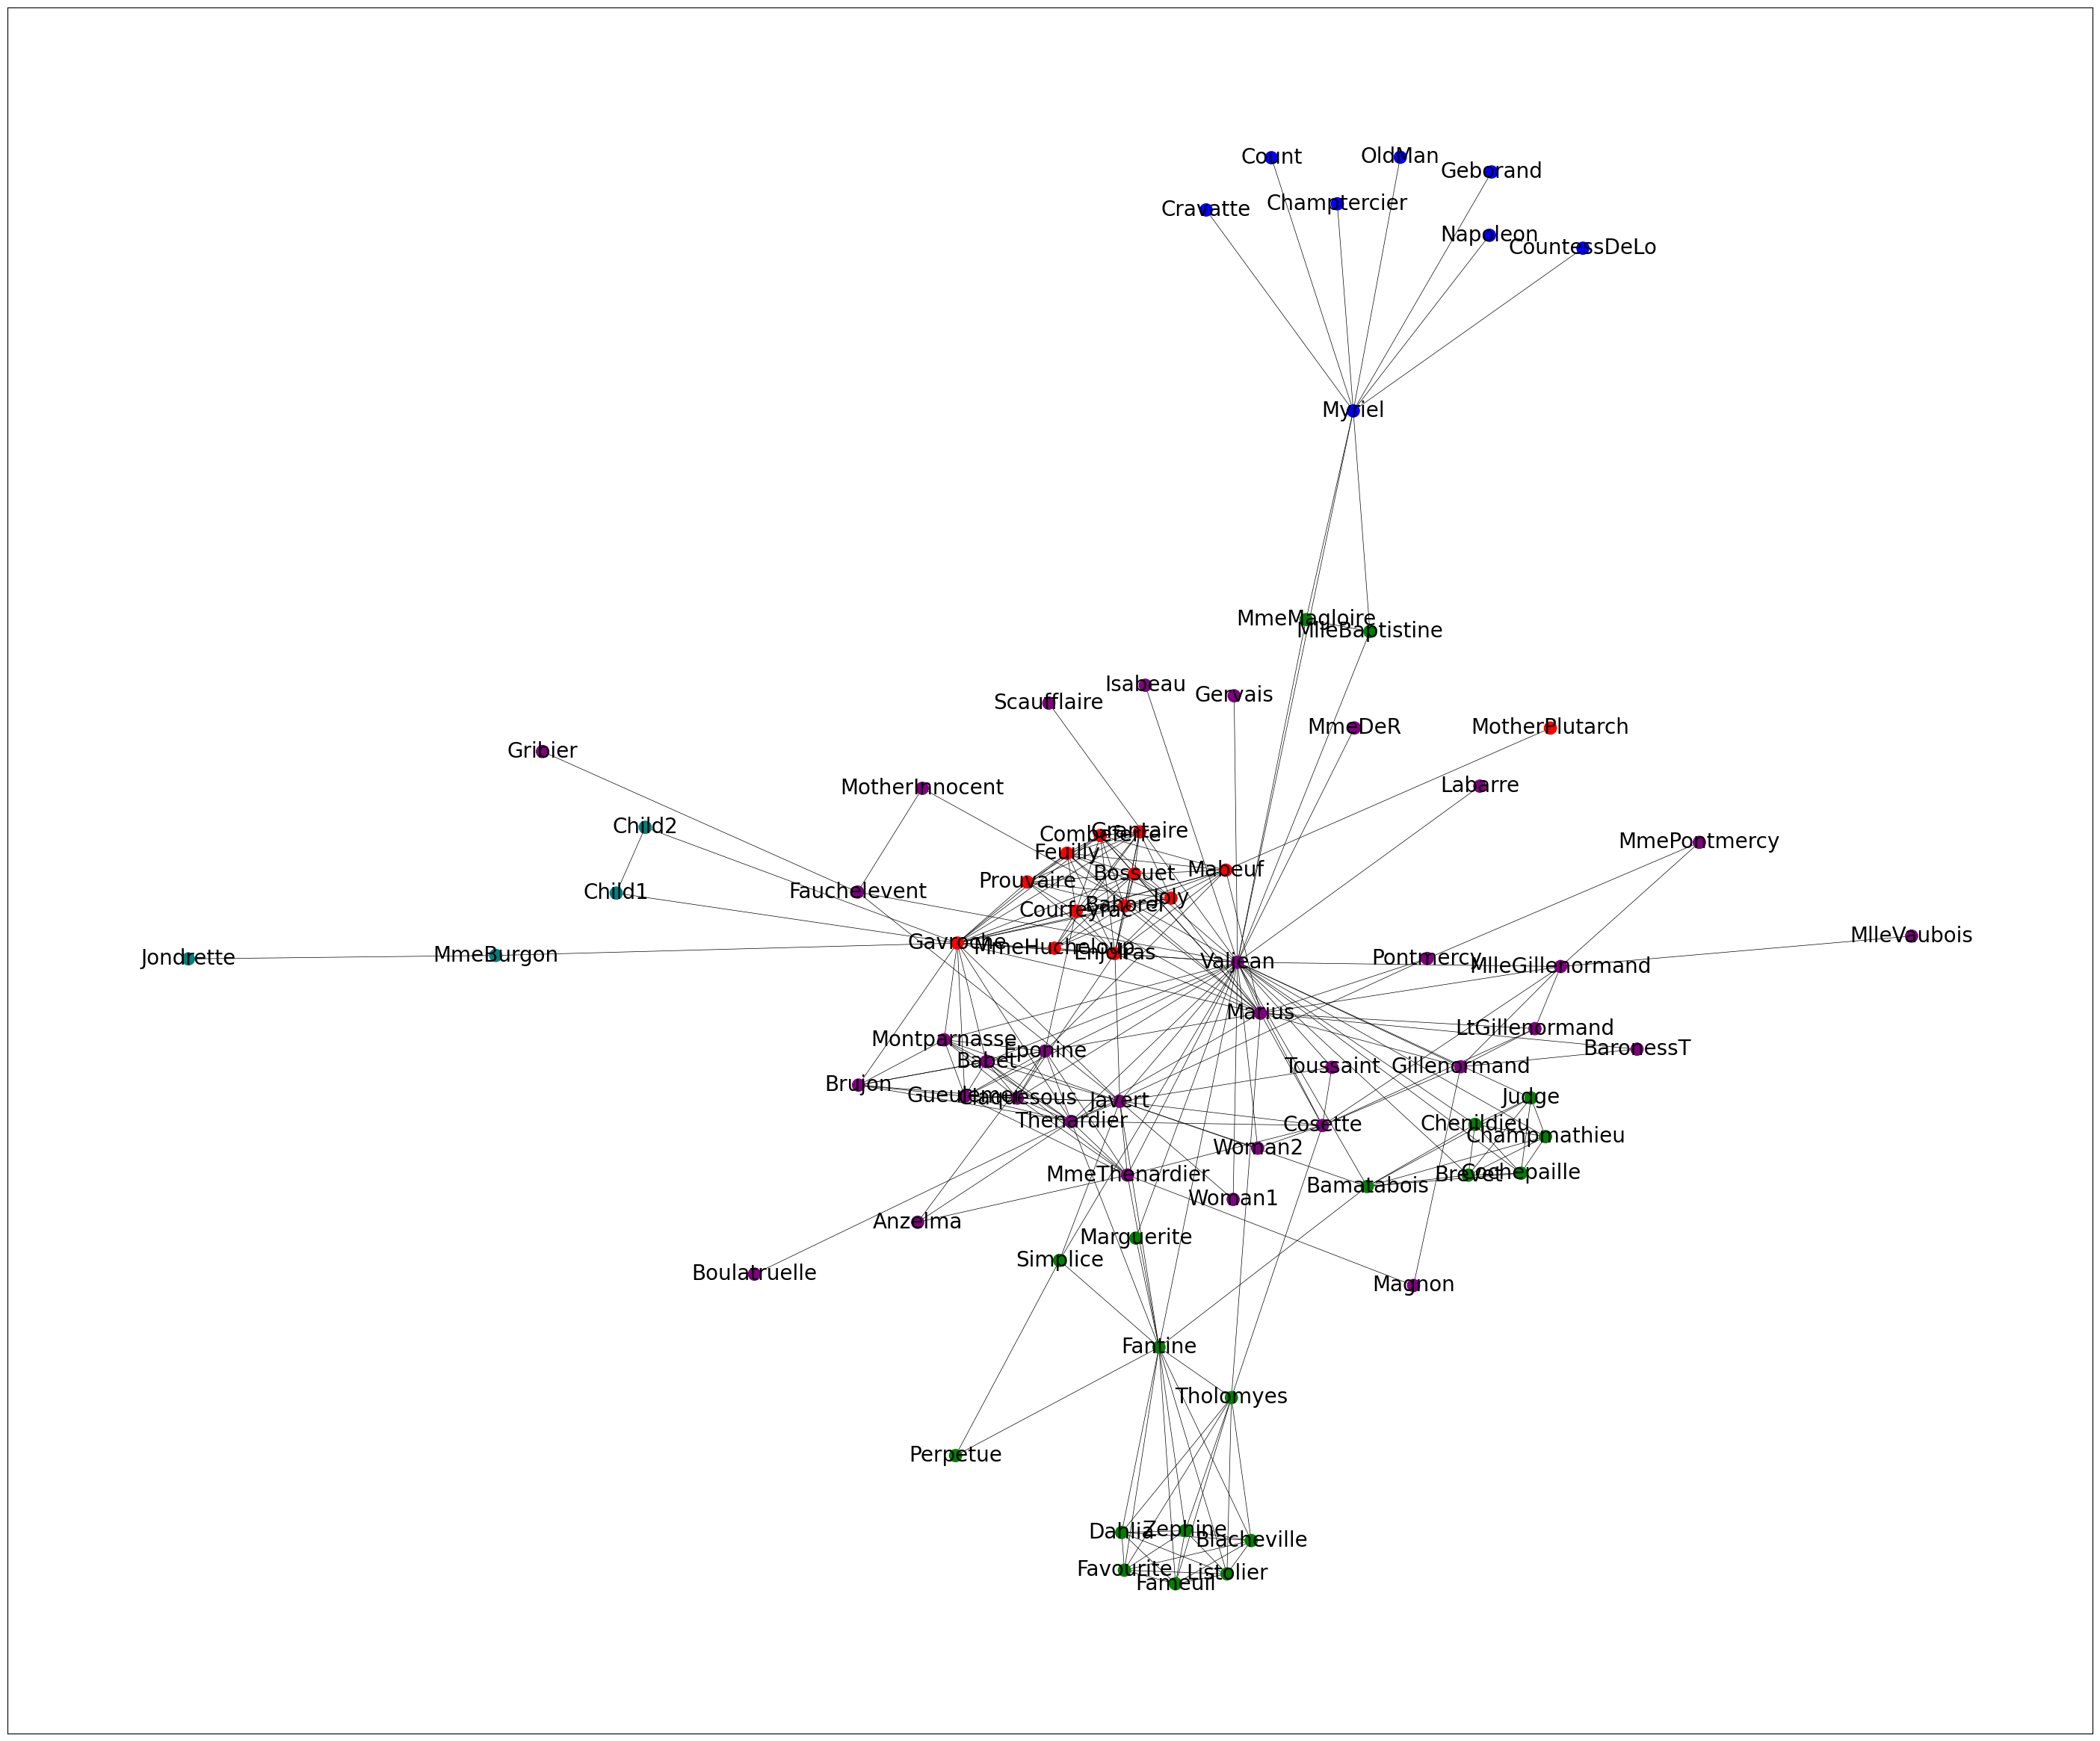

In [13]:
dwlesmis.draw_network(INPUT, True, colors)

In [14]:
lof = dwlesmis.culc_lof(vec, k = 4)

In [15]:
#node_annotationとlofの値を辞書型で結合
node_lof = dict(zip(node_annotation,lof))



In [18]:
node_lof["Valjean"]

1.0262447352722546